# Single Session Prediction

Only consider a single session in isolation. Use zero-shot inductive biases that Chronos 2 has, but probably not that good for our challenge.

### Read a session data

In [2]:
import pandas as pd

# Read the seen and unseen data
train_seen = pd.read_parquet("../data/bars_seen_train.parquet")
train_unseen = pd.read_parquet("../data/bars_unseen_train.parquet")

# Already set the timestamps
start_date = pd.to_datetime('2000-01-01')

train_seen['timestamp'] = start_date + pd.to_timedelta(train_seen['bar_ix'], unit='D')
train_unseen['timestamp'] = start_date + pd.to_timedelta(train_unseen['bar_ix'], unit='D')

display(train_seen)
display(train_unseen)


,bar_ix,session,open,high,low,close,timestamp
0,0,0,1.0000,1.0029,0.9986,0.9999,2000-01-01
1,0,1,1.0000,1.0024,0.9980,1.0011,2000-01-01
2,0,2,1.0000,1.0005,0.9952,0.9957,2000-01-01
3,0,3,1.0000,1.0008,0.9986,1.0008,2000-01-01
4,0,4,1.0000,1.0031,0.9996,1.0009,2000-01-01
...,...,...,...,...,...,...,...
1029995,49,995,0.9886,0.9913,0.9876,0.9913,2000-02-19
1029996,49,996,0.9916,0.9941,0.9899,0.9915,2000-02-19
1029997,49,997,0.9796,0.9801,0.9779,0.9796,2000-02-19
1029998,49,998,1.0123,1.0168,1.0123,1.0142,2000-02-19


,bar_ix,session,open,high,low,close,timestamp
1050000,50,0,1.0318,1.0375,1.0318,1.0367,2000-02-20
1050001,50,1,1.0283,1.0297,1.0261,1.0282,2000-02-20
1050002,50,2,1.0204,1.0217,1.0179,1.0202,2000-02-20
1050003,50,3,1.0117,1.0129,1.0112,1.0126,2000-02-20
1050004,50,4,1.0281,1.0296,1.0263,1.0274,2000-02-20
...,...,...,...,...,...,...,...
2079995,99,995,0.9833,0.9837,0.9811,0.9812,2000-04-09
2079996,99,996,1.0684,1.0685,1.0638,1.0661,2000-04-09
2079997,99,997,1.0058,1.0060,1.0019,1.0028,2000-04-09
2079998,99,998,1.0014,1.0033,1.0001,1.0028,2000-04-09


### Predict with Chronos 2

In [3]:
import pandas as pd  # requires: pip install 'pandas[pyarrow]'
from chronos import Chronos2Pipeline

def predict_session(SESSION_ID: int, seen=train_seen, unseen=train_unseen):
    # Prepare the session
    seen = seen[seen["session"] == SESSION_ID]
    unseen = unseen[unseen["session"] == SESSION_ID]

    pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="mps")

    pred_df = pipeline.predict_df(
        seen,
        future_df=None,
        prediction_length=50,  # Number of steps to forecast
        quantile_levels=[0.1, 0.5, 0.9],  # Quantile for probabilistic forecast
        id_column="session",  # Column identifying different time series
        timestamp_column="timestamp",  # Column with datetime information
        target="close",  # Column(s) with time series values to predict
    )

    import matplotlib.pyplot as plt  # requires: pip install matplotlib

    ts_context = seen.set_index("timestamp")["close"]
    ts_pred = pred_df.set_index("timestamp")
    ts_ground_truth = unseen.set_index("timestamp")["close"]

    ts_context.plot(label="historical data", color="xkcd:azure", figsize=(12, 3))
    ts_ground_truth.plot(label="future data (ground truth)", color="xkcd:grass green")
    ts_pred["predictions"].plot(label="forecast", color="xkcd:violet")
    plt.fill_between(
        ts_pred.index,
        ts_pred["0.1"],
        ts_pred["0.9"],
        alpha=0.7,
        label="prediction interval",
        color="xkcd:light lavender",
    )
    plt.legend()
    plt.show()

/Users/iliasmc/projects/hrt-datathon/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


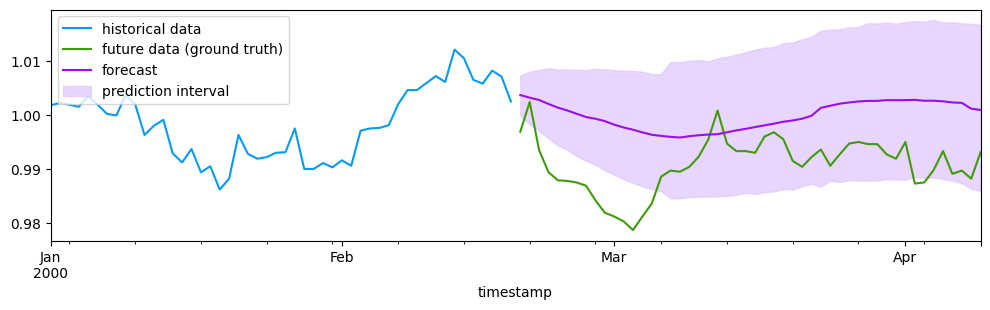

In [4]:
predict_session(SESSION_ID=137)

# Predict entire sequence

Take the entire group of time-series in context when predicting.

In [5]:

pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="mps")

all_pred_df = pipeline.predict_df(
    train_seen,
    future_df=None,
    prediction_length=50,  # Number of steps to forecast
    quantile_levels=[0.1, 0.5, 0.9],  # Quantile for probabilistic forecast
    id_column="session",  # Column identifying different time series
    timestamp_column="timestamp",  # Column with datetime information
    target="close",  # Column(s) with time series values to predict
)



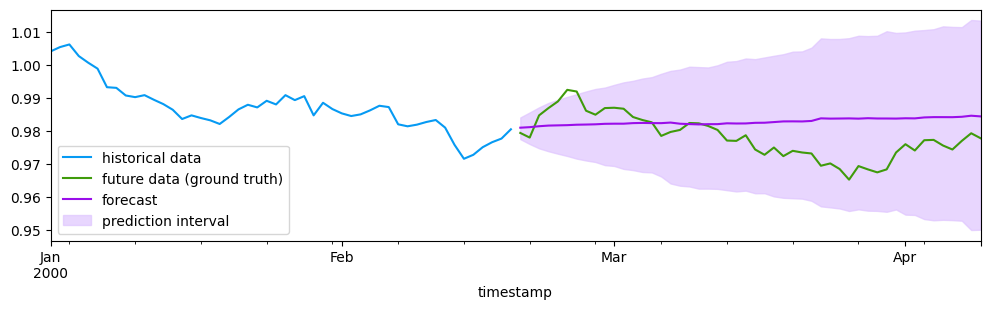

In [6]:
import matplotlib.pyplot as plt

DISPLAY_SESSION_ID = 123

display_seen = train_seen[train_seen["session"] == DISPLAY_SESSION_ID]
display_unseen = train_unseen[train_unseen["session"] == DISPLAY_SESSION_ID]
display_all_pred_df = all_pred_df[all_pred_df["session"] == DISPLAY_SESSION_ID]

ts_context = display_seen.set_index("timestamp")["close"]
ts_pred = display_all_pred_df.set_index("timestamp")
ts_ground_truth = display_unseen.set_index("timestamp")["close"]

ts_context.plot(label="historical data", color="xkcd:azure", figsize=(12, 3))
ts_ground_truth.plot(label="future data (ground truth)", color="xkcd:grass green")
ts_pred["predictions"].plot(label="forecast", color="xkcd:violet")
plt.fill_between(
    ts_pred.index,
    ts_pred["0.1"],
    ts_pred["0.9"],
    alpha=0.7,
    label="prediction interval",
    color="xkcd:light lavender",
)
plt.legend()
plt.show()

## Convert to a submission

In [56]:
import numpy as np

EPSILON = 0  # minimum predicted return to trade (0.2%)

# Close at bar 49 (halfway) for each session
close_halfway = train_seen.groupby('session')['close'].last().rename('close_halfway')

# At bar 99: median prediction and CI bounds (q10, q90) for each session
pred_last = all_pred_df.groupby('session').last()[['predictions', '0.1', '0.9']]
pred_last.columns = ['pred_close_end', 'q10_end', 'q90_end']

submission_df = close_halfway.to_frame().join(pred_last)

predicted_return = (submission_df['pred_close_end'] / submission_df['close_halfway']) - 1

# Normalised CI width as a fraction of the halfway price
ci_width = (submission_df['q90_end'] - submission_df['q10_end']) / submission_df['close_halfway']

# Scale down when the model is uncertain (wide CI), scale up when confident
# signal = predicted_return / ci_width  (units: return per unit of uncertainty)
signal = predicted_return / ci_width

# Only trade when the raw predicted move exceeds epsilon; otherwise hold flat
submission_df['target_position'] = np.where(
    predicted_return > EPSILON,
    2,
    0.0,
)

submission = submission_df[['target_position']].reset_index()[['session', 'target_position']].sort_values('session')
n_trading = (submission['target_position'] != 0).sum()
display(submission.head(10))
print(f"Trading {n_trading}/{len(submission)} sessions (epsilon={EPSILON})")
submission.to_csv('submission_train_chronos.csv', index=False)
print("Saved submission_train_chronos.csv")

,session,target_position
0,0,0.0
1,1,0.0
2,2,0.0
3,3,0.0
4,4,2.0
5,5,2.0
6,6,0.0
7,7,0.0
8,8,2.0
9,9,2.0


Trading 496/1000 sessions (epsilon=0)
Saved submission_train_chronos.csv


## Compute Sharpe

Sharpe ratio on train (Chronos-2 median forecast): 2.2854
Mean PnL: 0.003925
Std  PnL: 0.027491
Win rate: 29.50%


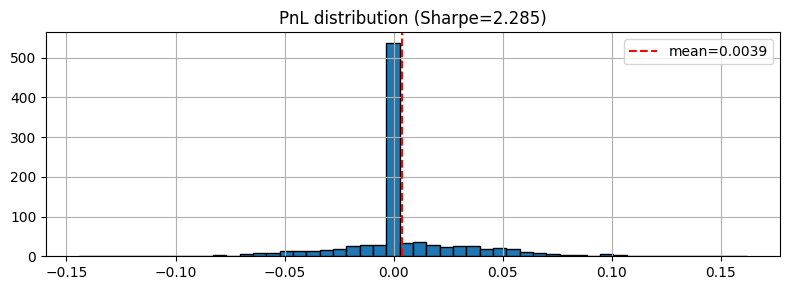

In [57]:
import numpy as np

# Actual close at bar 99 (end of session)
close_end = train_unseen.groupby('session')['close'].last().rename('close_end')

eval_df = submission.set_index('session').join(close_halfway).join(close_end)

# pnl_i = target_position_i * (close_end_i / close_halfway_i - 1)
eval_df['pnl'] = eval_df['target_position'] * (eval_df['close_end'] / eval_df['close_halfway'] - 1)

sharpe = np.mean(eval_df['pnl']) / np.std(eval_df['pnl']) * 16

print(f"Sharpe ratio on train (Chronos-2 median forecast): {sharpe:.4f}")
print(f"Mean PnL: {eval_df['pnl'].mean():.6f}")
print(f"Std  PnL: {eval_df['pnl'].std():.6f}")
print(f"Win rate: {(eval_df['pnl'] > 0).mean():.2%}")

import matplotlib.pyplot as plt
eval_df['pnl'].hist(bins=50, figsize=(8, 3), edgecolor='k')
plt.axvline(eval_df['pnl'].mean(), color='red', linestyle='--', label=f'mean={eval_df["pnl"].mean():.4f}')
plt.title(f'PnL distribution (Sharpe={sharpe:.3f})')
plt.legend()
plt.tight_layout()
plt.show()